In [ ]:
import datasets

In [ ]:
dataset = datasets.load_dataset(
    "m-aliabbas/idrak_timit_subsample1",
    split = "train",
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

data/train-00000-of-00001-aeb35d2d506d38(…):   0%|          | 0.00/29.5M [00:00<?, ?B/s]

data/test-00000-of-00001-0dca1a897ce597d(…):   0%|          | 0.00/1.88M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1296 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/324 [00:00<?, ? examples/s]

In [ ]:
data = next(iter(dataset))
audio = data["audio"]["array"]
sample_rate = data["audio"]["sampling_rate"]
transcript = data["transcription"]

In [ ]:
data

{'audio': <datasets.features._torchcodec.AudioDecoder at 0x7da3d2f41b50>,
 'transcription': 'don t ask me to carry an oily rag like that'}

In [ ]:
print(audio.shape)
print(sample_rate)
print("Audio Length: ", audio.size / sample_rate)
print(transcript)

(35840,)
16000
Audio Length:  2.24
don t ask me to carry an oily rag like that


In [ ]:
from IPython.display import Audio
Audio(audio, rate=sample_rate)

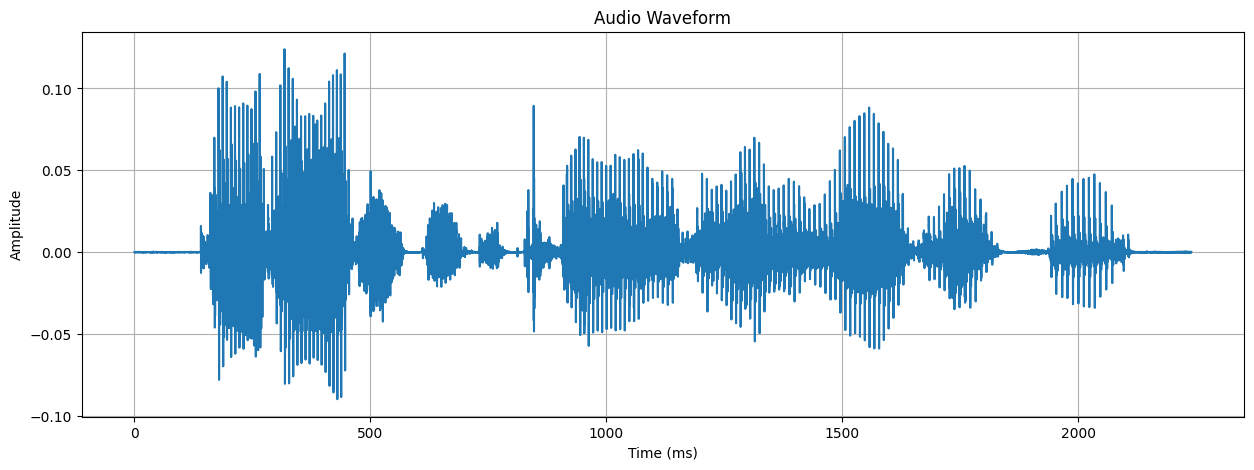

Audio length: 2240.00 ms


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

start_time_ms = 0
end_time_ms = 10000

start_idx = int(start_time_ms * sample_rate / 1000)
end_idx = int(end_time_ms * sample_rate / 1000)

audio_np = audio[start_idx:end_idx]

time_ms = np.arange(len(audio_np)) * (1000 / sample_rate)

plt.figure(figsize=(15, 5))
plt.plot(time_ms, audio_np)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Audio Waveform")
plt.grid(True)
plt.show()

print(f"Audio length: {len(audio_np) / sample_rate * 1000:.2f} ms")